# PipeSchrod Tutorial

`PipeSchrod` is a pipeline-oriented Python package designed for computing quantum bound-state properties (like energy levels, rms radii, and wave functions) for heavy quarkonia and other quantum systems. It uses the `>>` (pipe) operator to construct clean and intuitive computational graphs.

This tutorial gives detailed insights into the available **"verbs" (steps)** in `PipeSchrod`.

In [1]:
from pipeschrod import PipeSchrod
from pipeschrod.steps import (
    Cornell, Harmonic, Coulomb, WoodsSaxon, Morse,
    Grid, Solve, Summary, Compare, Plot, Export
)

## 1. Setting Up the System: `PipeSchrod`

Every pipeline starts with the `PipeSchrod` base object. This initialises the foundational state of the quantum system, including the masses of the interacting particles and their quantum numbers.

**Parameters**:
- `m1` (float): Mass of the first particle (GeV).
- `m2` (float): Mass of the second particle (GeV).
- `L` (int): Orbital angular momentum (default 0).
- `S` (int): Total spin (default 0).
- `J` (int): Total angular momentum (default 0).

**Example**: Initialising Charmonium ($c\bar{c}$) in the $1S$ state ($L=0, S=1, J=1$).

In [2]:
pipe = PipeSchrod(m1=1.4495, m2=1.4495, L=0, S=1, J=1)
print(pipe)

PipeSchrod(m1=1.4495, m2=1.4495, L=0, S=1, J=1 | pot=none | N=200, rmax=20.0 | solved=['—'])


## 2. Setting the Potential

`PipeSchrod` includes multiple potential steps that model different physical systems. You pipe one of these into your base system.

### `Cornell`
Models the strong interaction (e.g., quarkonium). $V(r) = -4\alpha/3r + br$.
- `alpha`, `b`, `C` parameters.
- `pot_type`: 1 = Coulomb+Linear, 2 = +Hyperfine correction, 3 = +Spin-Orbit+Tensor.

### `Harmonic`
Quantum harmonic oscillator: $V(r) = \frac{1}{2} m \omega^2 r^2$.

### `Coulomb`
Hydrogen-like potential.

### `WoodsSaxon`
Nuclear shell-model interactions.

### `Morse`
Diatomic molecule vibrations.

In [3]:
pipe = pipe >> Cornell(alpha=0.5317, b=0.1497, pot_type=1)

## 3. The `Grid` Step

The radial coordinate $r$ needs to be discretised. Use the `Grid` step to define the mesh.
- `N`: Number of points.
- `rmax`: Maximum radius in GeV⁻¹.
- `r0`: Minimum radius in GeV⁻¹ (avoids origin singularities).

In [4]:
pipe = pipe >> Grid(N=200, rmax=20.0, r0=0.1)

## 4. Solving the System: `Solve`

This step computes the Hamiltonian, finds eigenvalues, and generates wave functions. You can specify one or multiple methods.

**Available Solvers**:
- `"Matrix"` (Matrix Numerov)
- `"Numerov"` (Shooting Numerov)
- `"FGH"` (Fourier Grid Hamiltonian)
- `"Salpeter"` (Relativistic Salpeter equation)
- `"all"` (Run all natively supported solvers)

In [5]:
# Runs both FGH and Salpeter methods sequentially
pipe = pipe >> Solve("FGH", "Salpeter")

## 5. Output Verification: `Summary` and `Compare`

To view the computed physical properties (binding energies, RMS radii, etc.), use the info verbs.

- `Summary(n_states=...)`: Generates a detailed eigenvalue table for a specific method (defaults to the last solved method).
- `Compare(n_states=...)`: Generates a side-by-side table comparing the results of *all* solved configurations currently stored in the pipe.

In [6]:
# Print detailed results specifically for the FGH solver
pipe >> Summary(method="FGH", n_states=5)

# Compare FGH and Salpeter side-by-side
pipe >> Compare(n_states=5)

╭──────────────────────────────────────────────  PipeSchrod — FGH  ───────────────────────────────────────────────╮
│                                                                                                                 │
│   Method    : FGH                                                                                               │
│   Potential : cornell_type1                                                                                     │
│   m₁, m₂   : 1.4495 GeV,  1.4495 GeV                                                                            │
│   μ         : 0.724750 GeV                                                                                      │
│   L, S, J   : 0,  1,  1                                                                                         │
│   Grid N    : 200  (h = 0.10000 GeV⁻¹,  rmax = 20.0 GeV⁻¹)                                                      │
│   Threshold : 2.89900 GeV  (2m)                                                                                 │
│   Bound states: 9                                                                                               │
│   CPU time  : 37.0 ms                                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                     Eigenvalue Table  —  FGH  ·  cornell_type1                     
╭───┬───────┬──────────┬──────────┬────────────┬───────┬─────────────┬─────────────╮
│ n │ State │ E (GeV)  │ E (MeV)  │ B.E. (MeV) │ Nodes │ ⟨r⟩ (GeV⁻¹) │ rms (GeV⁻¹) │
├───┼───────┼──────────┼──────────┼────────────┼───────┼─────────────┼─────────────┤
│ 1 │  1S   │ 3.049114 │ 3049.114 │  150.114   │   0   │   1.8591    │   2.0815    │
├───┼───────┼──────────┼──────────┼────────────┼───────┼─────────────┼─────────────┤
│ 2 │  2S   │ 3.651087 │ 3651.087 │  752.087   │   1   │   3.9985    │   4.3488    │
├───┼───────┼──────────┼──────────┼────────────┼───────┼─────────────┼─────────────┤
│ 3 │  3S   │ 4.065525 │ 4065.525 │  1166.525  │   2   │   5.6892    │   6.1893    │
├───┼───────┼──────────┼──────────┼────────────┼───────┼─────────────┼─────────────┤
│ 4 │  4S   │ 4.412641 │ 4412.641 │  1513.641  │   3   │   7.1551    │   7.7922    │
├───┼───────┼──────────┼──────────┼────────────┼───────┼─────────────┼─────────────┤
│ 5 │  5S   │ 4.721783 │ 4721.783 │  1822.783  │   4   │   8.4809    │   9.2441    │
╰───┴───────┴──────────┴──────────┴────────────┴───────┴─────────────┴─────────────╯

    PipeSchrod — Method Comparison  (GeV)    
                                             
  n   State     FGH      Salpeter   Δ (MeV)  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  1    1S     3.049114   2.969169   79.944   
                                             
  2    2S     3.651087   3.561934   89.153   
                                             
  3    3S     4.065525   3.954982   110.543  
                                             
  4    4S     4.412641   4.276935   135.706  
                                             
  5    5S     4.721783   4.558847   162.936  
                                             

           ╷          ╷      
  Method   │ CPU time │ N    
╶──────────┼──────────┼─────╴
  FGH      │ 37.0 ms  │ 200  
  Salpeter │ 336.5 ms │ 200  
           ╵          ╵      

Method,E₁,Bound states,CPU
FGH,3.04911 GeV,9,37.0 ms
Salpeter,2.96917 GeV,11,336.5 ms


## 6. Visualisations: `Plot`

The `Plot` step processes the results and automatically builds rich graphical representations using `matplotlib`.

**Available Plot Targets**:
- `"dashboard"`: A 4-panel overview displaying everything below.
- `"wavefunctions"`: Computes and plots the normalised radial functions $u(r)$.
- `"densities"`: Plots spatial probability densities $|u(r)|^2$.
- `"potential"`: Draws $V(r)$ overlaid with the horizontal energy levels.
- `"spectrum"`: Generates a mass spectrum bar chart.
- `"compare_wf"`: Plots the ground state wavefunctions computed from *all* solvers simultaneously for structural comparison.
- `"compare_E"`: Side-by-side energy bar chart across methods.
- `"convergence"`: Ground-state energy vs grid size N.
- `"sensitivity"`: Potential shape and $E_1$ vs parameter $\alpha$ or $b$.

You can save the plots cleanly into a directory using `save="./path"` and silence `plt.show()` inline pops using `show=False`.

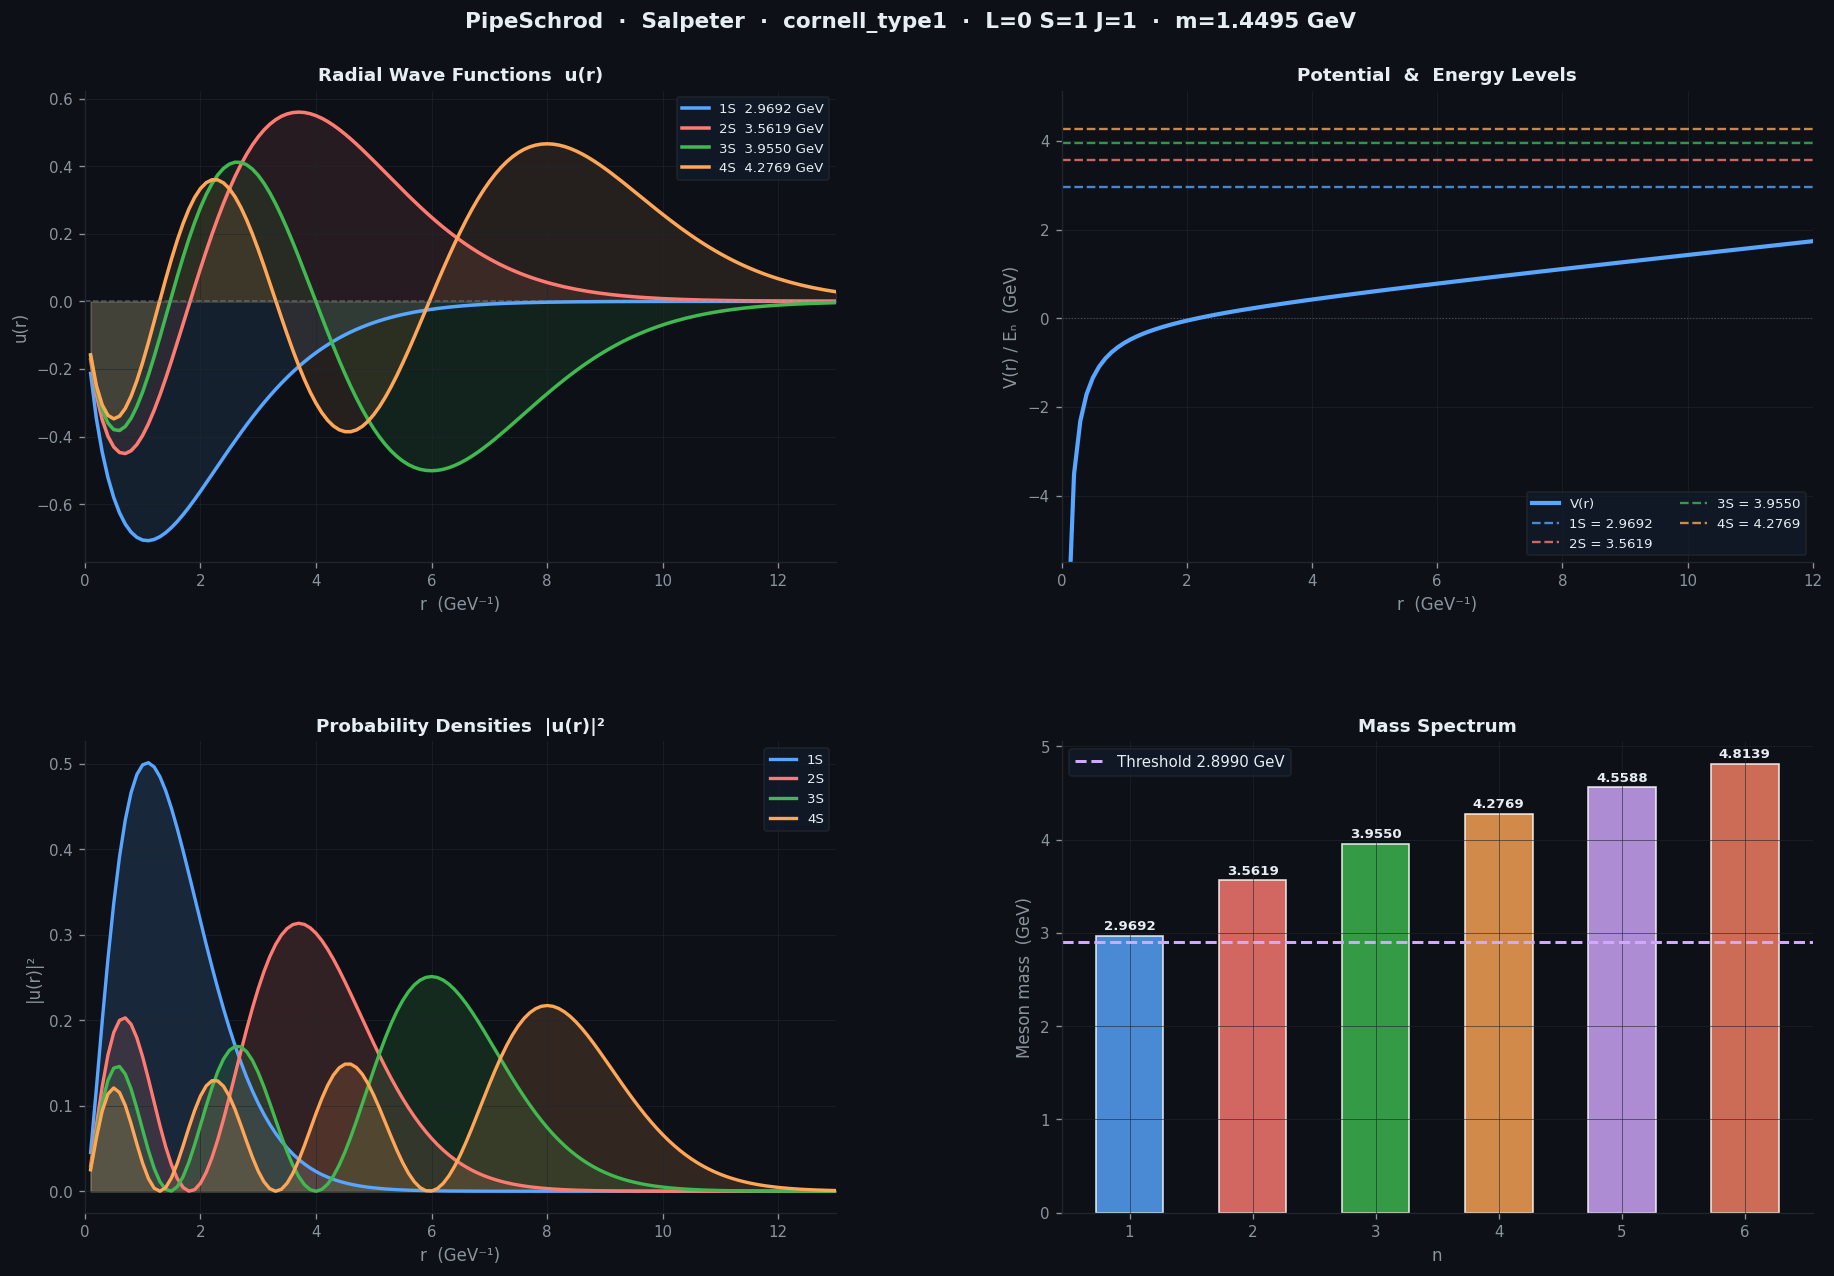

Method,E₁,Bound states,CPU
FGH,3.04911 GeV,9,37.0 ms
Salpeter,2.96917 GeV,11,336.5 ms


In [7]:
# Displays the main graphical 4-panel dashboard
pipe >> Plot("dashboard", n_states=4)

## 7. Extracting Data: `Export`

Finally, `Export` gives you the ability to save standard result sets for publication or further parsing.

- `fmt="csv"`: Saves the standard eigenvalue table.
- `fmt="json"`: Serialises the exact physical properties for strict reproducibility.
- `fmt="csv_compare"`: Saves a multi-column energy table separating methodologies.

In [ ]:
import os
os.makedirs("./pipeschrod_output", exist_ok=True)

pipe >> Export("csv", path="./pipeschrod_output/FGH_charmonium.csv", method="FGH")
pipe >> Export("csv_compare", path="./pipeschrod_output/Methods_Comparison.csv")

## 8. Conclusion: Building "One-Liners"

Every step returns the `PipeSchrod` state itself, which makes one-liners straightforward and composable:

     PipeSchrod — Method Comparison  (GeV)     
                                               
  n   State    Matrix        FGH      Δ (MeV)  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  1    1S     9.106382    9.122605    16.223   
                                               
  2    2S     9.764491    9.771769     7.278   
                                               
  3    3S     10.140824   10.146827    6.003   
                                               

         ╷          ╷      
  Method │ CPU time │ N    
╶────────┼──────────┼─────╴
  Matrix │ 51.6 ms  │ 300  
  FGH    │ 30.4 ms  │ 300  
         ╵          ╵      

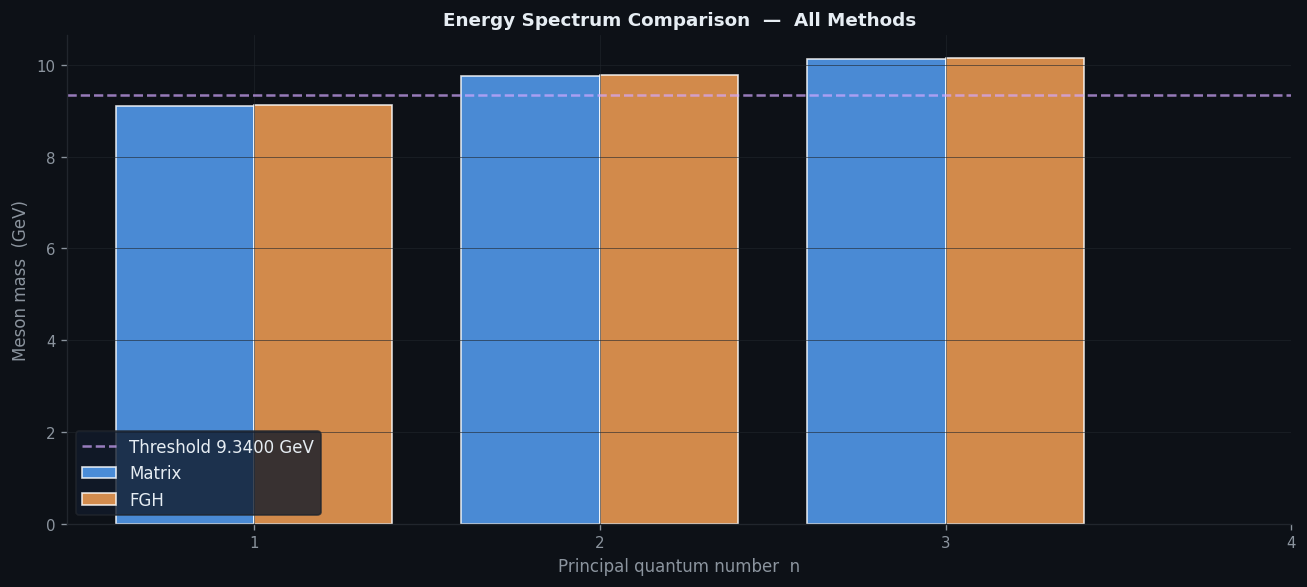

Finished run!


In [8]:
bottomonium = (
    PipeSchrod(m1=4.67, m2=4.67, L=0, S=1, J=1)
    >> Cornell(alpha=0.471, b=0.192, pot_type=1)
    >> Grid(N=300, rmax=25.0)
    >> Solve("Matrix", "FGH")
    >> Compare(n_states=4)
    >> Plot("compare_E", show=True)
)
print("Finished run!")